# Part 1 - Introduction
The MotifCompendium package offers you a way to organize, store, cluster, and analyze information about motifs in an easy to use and efficient manner.

Let's walk through how to use the package!

Let's begin by importing the MotifCompendium package!

In [1]:
import MotifCompendium

Now let's suppose we have motifs from multiple Modisco runs that we want to analyze. First, we can a dictionary of model name --> Modisco file path. Then, we can directly build a MotifCompendium object by using the build_from_modisco() function.

In [2]:
modisco_dict = {
    "cardiomyocyte": "/oak/stanford/groups/akundaje/salil512/resources/MotifCompendium_Tutorial_Resources/cardiomyocyte_LV_H_modisco_output.h5",
    "endothelial": "/oak/stanford/groups/akundaje/salil512/resources/MotifCompendium_Tutorial_Resources/endothelial_LV_H_modisco_output.h5",
}
mc = MotifCompendium.build_from_modisco(modisco_dict)
print(mc)

Motif Compendium with 88 motifs.
                            name  num_seqlets          model posneg
0    cardiomyocyte-pos.pattern_0        24730  cardiomyocyte    pos
1    cardiomyocyte-pos.pattern_1        23251  cardiomyocyte    pos
2   cardiomyocyte-pos.pattern_10         4122  cardiomyocyte    pos
3   cardiomyocyte-pos.pattern_11         4008  cardiomyocyte    pos
4   cardiomyocyte-pos.pattern_12         3352  cardiomyocyte    pos
..                           ...          ...            ...    ...
83     endothelial-pos.pattern_5         3338    endothelial    pos
84     endothelial-pos.pattern_6         2977    endothelial    pos
85     endothelial-pos.pattern_7         2358    endothelial    pos
86     endothelial-pos.pattern_8         2115    endothelial    pos
87     endothelial-pos.pattern_9         2006    endothelial    pos

[88 rows x 4 columns]


And just like that we have a MotifCompendium object we can begin to work with! But what happened in the build_from_modisco() function and what is a MotifCompendium object?

In the back end, all 88 motifs were read from both Modisco outputs. Then, the pairwise similarity of all 88 motifs were computed. The similarity between any two motifs is a score between 0 and 1 where 0 represents that the motifs have no overlap and 1 represents that the two motifs are identical. The similarity score takes into accounts all possible orientations of the motifs being compared.

The MotifCompendium object is the backbone of this package. It is an object that you can use to better analyze, organize, and store your clusters. The MotifCompendium object has 5 attributes:
- motifs: The motifs themselves.
- similarity: A matrix containing pairwise similarity scores between the motifs.
- alignment_fr: A matrix containing alignment information between the motifs.
- alignment_h: A matrix containing alignment information between the motifs.
- metadata: A DataFrame that stores information about each motif.

The rest of this tutorial will focus on the MotifCompendium object and how to build/interface with it before moving onto deeper analysis.

# Part 2 - Looking inside a MotifCompendium (!important)

Let's look at the motifs, similarity matrix, and metadata inside a MotifCompendium object.

In [3]:
print(mc.motifs.shape)

(88, 30, 8)


Notice how the motifs are of shape (88, 30, 8). That is because when building from Modisco, motifs are transformed from a 4 channel representation (ACGT) to an 8 channel sign-aware representation (A+, A-, C+, C-, G-, G+, T-, T+). This representation is beneficial to the MotifCompendium's similarity calculations.

Also, by default, the motifs have undergone information-content scaling to decrease the importance of positions with low base information content. It is highly recommended that you do this! But you can always turn it off by doing `MotifCompendium.build_from_modisco(modisco_dict, ic=False)`.

Now, let's look at the similarity matrix:

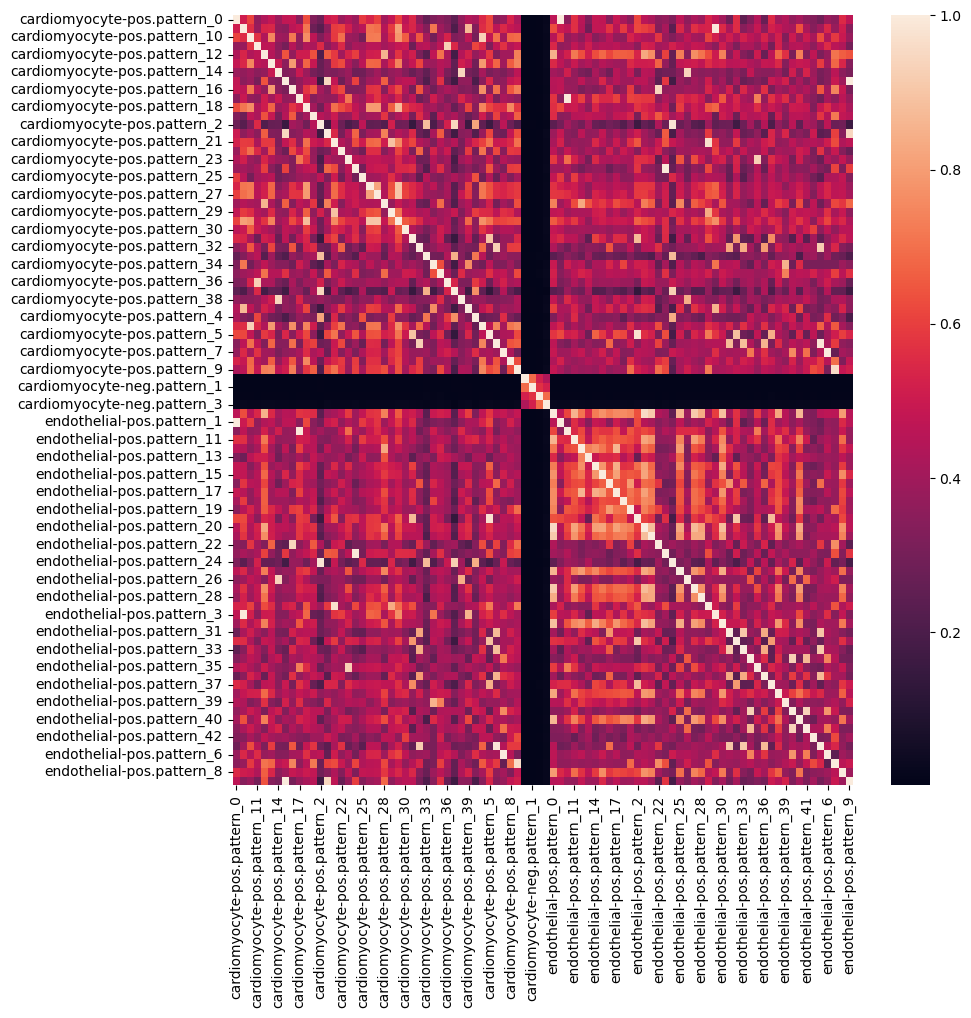

In [4]:
mc.heatmap(show=True, label=True)

The similarity matrix has some interesting structure! Notice that there are 1s all along the diagonal. Also, notice how the set of motifs (41-44) that are completely distinct from every other motif. Keep that in mind, as we will dig more into those in a bit!

The similarity matrix is something you don't usually need to access directly. There are built in utilities that will be covered in subsequent tutorials for almost any way that you would like to access the similarity matrix.

Now, let's look at the most flexible part of the MotifCompendium object: the metadata.

In [5]:
mc.metadata

,name,num_seqlets,model,posneg
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos
...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos
84,endothelial-pos.pattern_6,2977,endothelial,pos
85,endothelial-pos.pattern_7,2358,endothelial,pos
86,endothelial-pos.pattern_8,2115,endothelial,pos


The metadata is just a Pandas DataFrame. But it is deeply integrated into the MotifCompendium object. Each row corresponds exactly to one of the motifs. Some columns are provided by default. But other columns can be added as the user sees fit.

Most importantly, you can **index and subset** the MotifCompendium object based off of its metadata just like you would any other DataFrame. This design was done with the goal of providing the user with a flexibile framework with which they could perform any analysis they are interested in doing.

Let's see some examples of this:

In [6]:
mc["test_column"] = "test"
mc.metadata

,name,num_seqlets,model,posneg,test_column
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,test
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,test
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,test
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,test
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,test
...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,test
84,endothelial-pos.pattern_6,2977,endothelial,pos,test
85,endothelial-pos.pattern_7,2358,endothelial,pos,test
86,endothelial-pos.pattern_8,2115,endothelial,pos,test


Notice how we used Pandas syntax to add a column to the MotifCompendium.

We can even use this syntax to subset our analysis to certain motifs!

In [7]:
mc[mc["model"] == "cardiomyocyte"].metadata

,name,num_seqlets,model,posneg,test_column
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,test
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,test
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,test
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,test
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,test
5,cardiomyocyte-pos.pattern_13,3313,cardiomyocyte,pos,test
6,cardiomyocyte-pos.pattern_14,2975,cardiomyocyte,pos,test
7,cardiomyocyte-pos.pattern_15,2457,cardiomyocyte,pos,test
8,cardiomyocyte-pos.pattern_16,2131,cardiomyocyte,pos,test
9,cardiomyocyte-pos.pattern_17,1742,cardiomyocyte,pos,test


It's important to remember: this DataFrame-like syntax does **not** just affect the metadata. It affects the whole object! Let's see how we can make use of this feature.

Remember the weird structure in the similarity matrix above? Could the motifs with no similarity to the other motifs just be negative motifs? Let's investigate!

Motif Compendium with 4 motifs.
                          name  num_seqlets          model posneg test_column
0  cardiomyocyte-neg.pattern_0           55  cardiomyocyte    neg        test
1  cardiomyocyte-neg.pattern_1           50  cardiomyocyte    neg        test
2  cardiomyocyte-neg.pattern_2           46  cardiomyocyte    neg        test
3  cardiomyocyte-neg.pattern_3           22  cardiomyocyte    neg        test


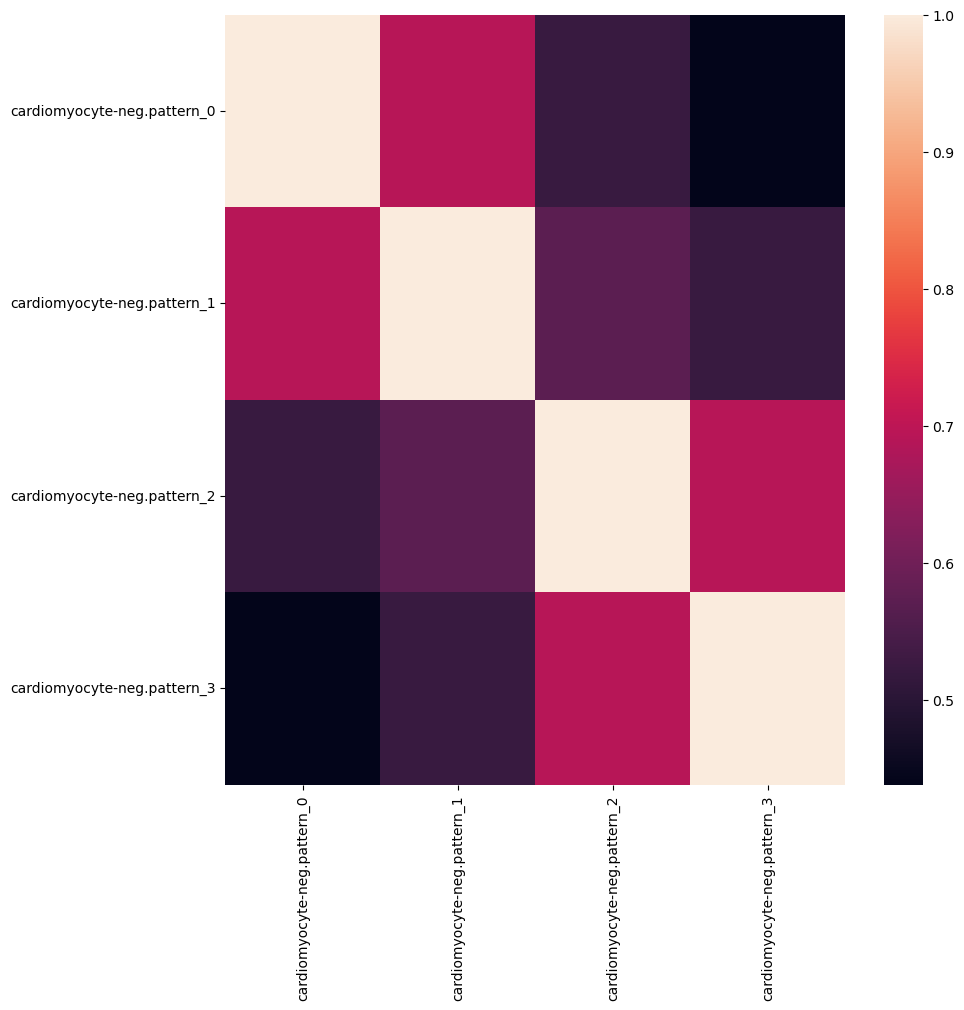

In [8]:
mc_posneg = mc[mc["posneg"] == "neg"]
print(mc_posneg)
mc_posneg.heatmap(show=True, label=True)

These were the motifs that were sticking out in the previous analysis! By subsetting the MotifCompendium object appropriately, we were very easily able to access just the motifs that we were interested in and look at their internal similarity structure.

# Part 3 - Building/saving/loading

MotifCompendium objects can easily be stored and loaded.

In [9]:
mc.save("test_compendium.mc")

In [10]:
mc_loaded = MotifCompendium.load("test_compendium.mc")
print(mc_loaded)

Motif Compendium with 88 motifs.
                            name  num_seqlets          model posneg  \
0    cardiomyocyte-pos.pattern_0        24730  cardiomyocyte    pos   
1    cardiomyocyte-pos.pattern_1        23251  cardiomyocyte    pos   
2   cardiomyocyte-pos.pattern_10         4122  cardiomyocyte    pos   
3   cardiomyocyte-pos.pattern_11         4008  cardiomyocyte    pos   
4   cardiomyocyte-pos.pattern_12         3352  cardiomyocyte    pos   
..                           ...          ...            ...    ...   
83     endothelial-pos.pattern_5         3338    endothelial    pos   
84     endothelial-pos.pattern_6         2977    endothelial    pos   
85     endothelial-pos.pattern_7         2358    endothelial    pos   
86     endothelial-pos.pattern_8         2115    endothelial    pos   
87     endothelial-pos.pattern_9         2006    endothelial    pos   

   test_column  
0         test  
1         test  
2         test  
3         test  
4         test  
..         .

Saving allows you to not have to recompute similarity each time you want to perform an analysis, and it saves changes you may have made to the metadata or your object.

For very large MotifCompendium, loading itself can take some time. If you just want to look what is inside a MotifCompendium without fully loading all of the matrices associated with it, you can inspect() the file. This displays an object summary and returns the object's metadata.

In [11]:
MotifCompendium.inspect("test_compendium.mc")

Motif Compendium with 88 motifs.
                            name  num_seqlets          model posneg  \
0    cardiomyocyte-pos.pattern_0        24730  cardiomyocyte    pos   
1    cardiomyocyte-pos.pattern_1        23251  cardiomyocyte    pos   
2   cardiomyocyte-pos.pattern_10         4122  cardiomyocyte    pos   
3   cardiomyocyte-pos.pattern_11         4008  cardiomyocyte    pos   
4   cardiomyocyte-pos.pattern_12         3352  cardiomyocyte    pos   
..                           ...          ...            ...    ...   
83     endothelial-pos.pattern_5         3338    endothelial    pos   
84     endothelial-pos.pattern_6         2977    endothelial    pos   
85     endothelial-pos.pattern_7         2358    endothelial    pos   
86     endothelial-pos.pattern_8         2115    endothelial    pos   
87     endothelial-pos.pattern_9         2006    endothelial    pos   

   test_column  
0         test  
1         test  
2         test  
3         test  
4         test  
..         .

,name,num_seqlets,model,posneg,test_column
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,test
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,test
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,test
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,test
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,test
...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,test
84,endothelial-pos.pattern_6,2977,endothelial,pos,test
85,endothelial-pos.pattern_7,2358,endothelial,pos,test
86,endothelial-pos.pattern_8,2115,endothelial,pos,test


In the example above, we built the MotifCompendium on a single CPU. However, if you have access to more CPUs, you can make use of multiople of them to parallelize the process!

The added CPUs help speed up parallelization of the similarity calculation and also help parallelize the loading of the Modisco outputs. These parallelizations will be really crucial to take advantage of if you have 100s or 1000s of Modisco outputs to load and process.

In [12]:
mc_multi_cpu = MotifCompendium.build_from_modisco(modisco_dict, max_cpus=2)
print(mc_multi_cpu)

Motif Compendium with 88 motifs.
                            name  num_seqlets          model posneg
0    cardiomyocyte-pos.pattern_0        24730  cardiomyocyte    pos
1    cardiomyocyte-pos.pattern_1        23251  cardiomyocyte    pos
2   cardiomyocyte-pos.pattern_10         4122  cardiomyocyte    pos
3   cardiomyocyte-pos.pattern_11         4008  cardiomyocyte    pos
4   cardiomyocyte-pos.pattern_12         3352  cardiomyocyte    pos
..                           ...          ...            ...    ...
83     endothelial-pos.pattern_5         3338    endothelial    pos
84     endothelial-pos.pattern_6         2977    endothelial    pos
85     endothelial-pos.pattern_7         2358    endothelial    pos
86     endothelial-pos.pattern_8         2115    endothelial    pos
87     endothelial-pos.pattern_9         2006    endothelial    pos

[88 rows x 4 columns]


While using multiple CPUs can help, for larger MotifCompendium, it will be important to make use of GPU-acceleration to efficiently compute motif similarity. If the appropriate packages/conda environment have been installed, you can make use of the gpu with the use_gpu flag. If you do that, though, use the max_chunk option so that you fit all calculations with the GPU's memory.

In [13]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
mc_gpu = MotifCompendium.build_from_modisco(modisco_dict, max_chunk=1000, use_gpu=True)
print(mc_gpu)

Motif Compendium with 88 motifs.
                            name  num_seqlets          model posneg
0    cardiomyocyte-pos.pattern_0        24730  cardiomyocyte    pos
1    cardiomyocyte-pos.pattern_1        23251  cardiomyocyte    pos
2   cardiomyocyte-pos.pattern_10         4122  cardiomyocyte    pos
3   cardiomyocyte-pos.pattern_11         4008  cardiomyocyte    pos
4   cardiomyocyte-pos.pattern_12         3352  cardiomyocyte    pos
..                           ...          ...            ...    ...
83     endothelial-pos.pattern_5         3338    endothelial    pos
84     endothelial-pos.pattern_6         2977    endothelial    pos
85     endothelial-pos.pattern_7         2358    endothelial    pos
86     endothelial-pos.pattern_8         2115    endothelial    pos
87     endothelial-pos.pattern_9         2006    endothelial    pos

[88 rows x 4 columns]


# 4 - Conclusion

This tutorial introduced you to the MotifCompendium package and the MotifCompendium object. It aimed to demonstrate how MotifCompendium could be built, loaded, saved, and manipulated in a flexible and efficient manner. For instruction on how to actually use the MotifCompendium for analyses, please go through the other tutorials. 